# ENGR 1451/2451 — Weekly Assignment 3
**10 points**

This assignment applies programming, normal-approximation, and central-limit-theorem ideas.


**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

No external data file is needed for this assignment.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


## LE3-1. Detecting abrupt changes in a sequence (2 pts)

Thickness is measured at consecutive positions along a coated sample. A change of **5 nm or more in magnitude** between neighboring positions is considered abrupt.

### A. Loop solution (1 pt)

Using `range`, an `if` statement, and `.append()`, calculate each change from one position to the next and store it in `changes_loop`. Store the position pairs with abrupt changes in `abrupt_pairs_loop`. **Report position numbers starting at 1**; for example, `(1, 2)` means the change from the first measurement to the second measurement.


In [11]:
thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]
settings = {"abrupt_change_nm": 5}

changes_loop = []
abrupt_pairs_loop = []

for i in range(len(thickness_nm)-1):
    change = thickness_nm[i+1] - thickness_nm[i]
    changes_loop.append(change)
    
    if abs(change) >= settings["abrupt_change_nm"]:
        abrupt_pairs_loop.append((i+1,i+2))

print(changes_loop)
print(abrupt_pairs_loop)

[2, -1, 6, 1, -3, 6, -1]
[(3, 4), (6, 7)]


### B. Vectorized solution (1 pt)

Convert the data to a NumPy array and use `np.diff()` to calculate the same changes without an explicit loop. Use a Boolean mask to identify abrupt changes. Verify agreement with the loop solution and report the affected position pairs.

**Answer:**
Vectorized solution agrees with loop solution

In [24]:
thickness_np = np.array(thickness_nm)

changes_np = np.diff(thickness_np)

print(changes_np)

abrupt_mask = abs(changes_np) >= settings["abrupt_change_nm"]

abrupt_indices = np.where(abrupt_mask)[0]

position_pair = list(zip(abrupt_indices+1, abrupt_indices +2))

print(position_pair)

verify_change = np.array_equal(changes_loop, changes_np)
verify_pairs = np.array_equal(abrupt_pairs_loop, position_pair)

print(verify_change)
print(verify_pairs)

[ 2 -1  6  1 -3  6 -1]
[(3, 4), (6, 7)]
True
True


## LE3-2. Raw scores and a normal approximation (2 pts)

For Part B, use a normal model with **mean = 50** and **SD = 10**. **Do not estimate these values from the raw scores.**

### A. Density histogram from raw data (1 pt)

Make a **density histogram** using the supplied equal-width bins. Then use `np.histogram(..., density=True)` to calculate the density heights and verify

\[
\sum_i (\text{density}_i)(\text{bin width}_i)=1.
\]

Also calculate the sum of the density heights. Why do the heights themselves not need to sum to 1?


1.0
0.2


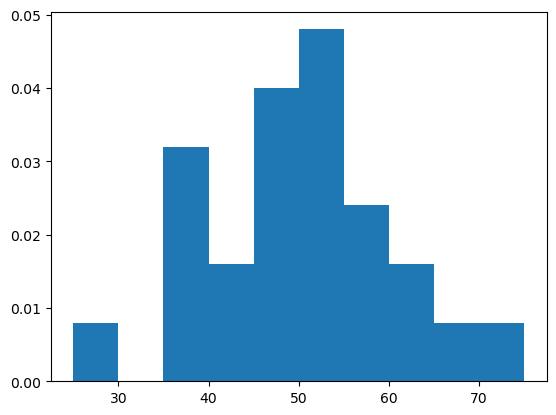

In [31]:
scores = np.array([
    39, 41, 47, 58, 65, 37, 37, 49, 56, 59, 62, 36, 48,
    52, 64, 29, 44, 47, 49, 52, 53, 54, 72, 50, 50
])

bins = np.arange(25, 76, 5)

plt.hist(scores, bins, density=True)

heights, edges = np.histogram(scores, bins, density=True)
width = np.diff(edges)
verify = (heights * width).sum()
print(verify)

print(heights.sum())

**Answer:**
The height sum is 0.2. The heights don't need to add up to 1 because the area of each bin here is normalized, not the heights (area is proportional)

### B. Approximation versus actual data (1 pt)

Using the supplied normal model with **mean = 50** and **SD = 10**, estimate the percentage and number of the 25 scores within **1.25 SDs** of the mean. Then count how many raw scores actually fall in that interval. Round the fitted count to the nearest whole student and compare.


In [41]:
mean = 50
SD = 10

model = norm(loc=50, scale=10)
upper_limit = mean + 1.25*SD
lower_limit = mean - 1.25*SD

percent = model.cdf(upper_limit) - model.cdf(lower_limit)
print(percent, "fraction of scores within 1.25 SDs")
print(percent*25, "number of scores within 1.25 SDs out of 25")

actual = (lower_limit <= scores) & (scores <= upper_limit)
print(actual.sum(),"actual sum")

0.7887004526662893 fraction of scores within 1.25 SDs
19.717511316657234 number of scores within 1.25 SDs out of 25
18 actual sum


**Answer:**
THe supplied normal model estimates 78.87% of the class, or approximately 20 students, are within 1.25 SDs of the mean. The actual count from the raw scores is 18, so it overestimated by about 2 students.

## LE3-3. Normal model for engineering specifications (4 pts)

Shaft diameters are modeled by a normal curve with \(\mu=10.00\) mm and \(\sigma=0.12\) mm. The acceptable range is **9.80–10.20 mm**. Assume the normal model is appropriate.

### A. Fraction meeting specification (1.5 pts)

Calculate the fitted percentages **below**, **within**, and **above** specification, and check that they total about 100%. Why are the two tail percentages equal?


In [49]:
mean_diameter = 10.00
std_diameter = 0.12
lower_spec = 9.80
upper_spec = 10.20

shaft_model = norm(loc=mean_diameter, scale=std_diameter)

below_spec = shaft_model.cdf(9.80)
within_spec = shaft_model.cdf(10.20) - shaft_model.cdf(9.80)
above_spec = shaft_model.sf(10.20)
print("below:", below_spec, "within:", within_spec, "above_spec:", above_spec)

total = below_spec + within_spec + above_spec
print(total)

below: 0.0477903522728153 within: 0.9044192954543695 above_spec: 0.0477903522728153
1.0


**Answer:**
The two tail percentages are equal because we are using a normal curve model that is symmetric on both sides of the curve. The range given is +/- 1.67 SDs away from the mean, so the tail percentages are an equal distance away from the mean.

### B. Upper 99th-percentile threshold (1 pt)

Find an upper threshold that only **1%** of shafts are expected to exceed. Use `ppf` or `isf`, then verify the result with a right-tail probability.


In [48]:
upper_thr = shaft_model.isf(.01)
print(upper_thr)

check = shaft_model.sf(upper_thr)
print(check)

10.2791617448849
0.010000000000000052


### C. Process drift (1.5 pts)

Suppose the process mean shifts to **10.05 mm**, while $\sigma=0.12$ mm and the specifications stay fixed. Recalculate the percentages below and above specification and the total percentage rejected. Compare with the original process. Which side now causes most rejections, and why?


In [50]:
shifted_mean = 10.05

shifted_model = norm(loc=shifted_mean, scale=std_diameter)

below_spec_shift = shifted_model.cdf(9.80)
within_spec_shift = shifted_model.cdf(10.20) - shifted_model.cdf(9.80)
above_spec_shift = shifted_model.sf(10.20)
print("below:", below_spec_shift, "within:", within_spec_shift, "above_spec:", above_spec_shift)

total = below_spec_shift + within_spec_shift + above_spec_shift
print(total)

below: 0.018610425189886332 within: 0.8757398011432562 above_spec: 0.10564977366685746
1.0


**Answer:**
Now only 87.57% of shafts are within range compared to 90.44% before. The above spec side now causes more rejections because the mean has shifted higher relative to the upper limit, so now we are finding the probability of landing -1.67 SDs and +1.25 SDs from the mean instead of +/- 1.67 SDs.

## LE3-4. CLT with a skewed process (2 pts)

For this exercise, we will start with an **exponential distribution**. An exponential distribution is a continuous distribution often used to model **waiting times**. It only produces positive values and is **strongly right-skewed**: short waiting times are common, while very long waiting times are possible but less common.

In NumPy,

```python
rng.exponential(scale=4.0, ...)
```

uses an exponential distribution with a **mean of 4 minutes**. We are using it because it gives us a clearly **non-normal starting distribution**, which makes the effect of the central limit theorem easier to see.

Run the starter code below to simulate the waiting times and view the distribution of individual observations.

### A. Averages of 4 versus 40 observations (1.5 pts)

Calculate the average of the first **4** waiting times in each row and the average of all **40** waiting times in each row.

1. For each set of averages, calculate the **mean** and **sample standard deviation** and summarize the results in a table.
2. Make a separate **density histogram** for each set of averages.
3. Compare the observed ratio of the sample standard deviations,

$
\frac{s_{\bar X_4}}{s_{\bar X_{40}}},
$

with the value predicted by the $1/\sqrt{n}$ relationship:

$
\frac{1/\sqrt{4}}{1/\sqrt{40}}
=
\sqrt{\frac{40}{4}}
=
\sqrt{10}
\approx 3.16.
$

Does your simulation approximately agree with this prediction?

Here, $s_{\bar X_4}$ is the sample standard deviation of the 5,000 simulated averages of 4 observations, and $s_{\bar X_{40}}$ is the sample standard deviation of the 5,000 simulated averages of 40 observations.


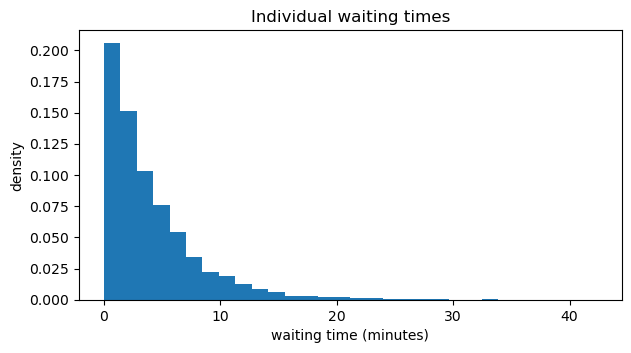

             4        40
mean  4.041293  3.995643
std   2.040821  0.628392


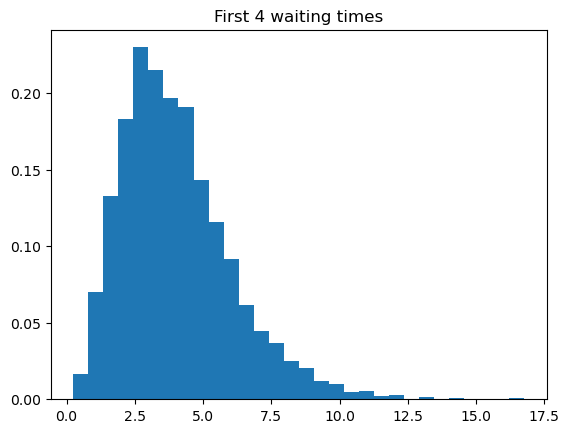

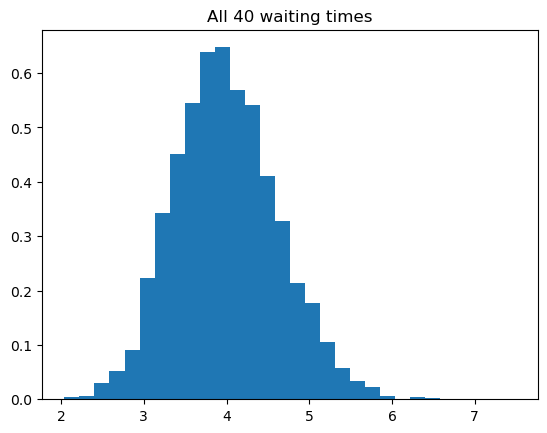

3.247687749048365 agrees relatively well with the prediction of 3.16


In [57]:
rng = np.random.default_rng(1451)
waiting_times = rng.exponential(scale=4.0, size=(5000, 40))

# First, look at the distribution of individual waiting times.
plt.figure(figsize=(7, 3.5))
plt.hist(waiting_times[:, 0], bins=30, density=True)
plt.xlabel("waiting time (minutes)")
plt.ylabel("density")
plt.title("Individual waiting times")
plt.show()

# The row averages are provided so you can focus on the CLT.
means_4 = waiting_times[:, :4].mean(axis=1)
means_40 = waiting_times.mean(axis=1)

comparison = pd.DataFrame(
    {
        "4":means_4,
        "40":means_40,
    }
)

print(comparison.agg(["mean", "std"]))

plt.hist(means_4, bins=30, density=True)
plt.title("First 4 waiting times")
plt.show()

plt.hist(means_40, bins=30, density=True)
plt.title("All 40 waiting times")
plt.show()

ratio = 2.040821 / 0.628392
print(ratio, "agrees relatively well with the prediction of 3.16")

### B. Interpret (0.5 pt)

Compare center, spread, and shape for the two distributions of averages. Explain what the simulation illustrates about the **central limit theorem**, and distinguish it from the **law of large numbers**.

**Answer:**
For just the first 4 waiting times, the mean is 4.04 and SD is 2.04. For all 40 waiting times, the mean is 3.99 and SD is 0.62. The first 4 waiting times have a larger spread and a tail skewed to the right. The central limit theorem states that as you take more and more large random samples and calculate their means, the distribution of those means becomes increasingly normal. This is shown by the difference in shape between the 1st 4 waiting times and all 40 histograms, with one appearing more right skewed and the other approx. normal. The law of large numbers is different because it says that as your sample size gets larger, the sample average gets closer to the population average. The calculations based on all 40 waiting times show a mean of 3.99, which is closer to mean=4 than just the 1st 4 waiting time calculations.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*

{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA3",
  "export_n": 1,
  "session_date": "2026-09-22",
  "messages": [
    {"i": 1, "who": "student", "text": "what does \"settings = {\"abrupt_change_nm\": 5}\" do in the context of LE3-1 A? Do I still need to define abrupt_change_nm?"},
    {"i": 2, "who": "tutor", "text": "`settings` is a dictionary — a container that maps keys to values. This one has a single key, the string `\"abrupt_change_nm\"`, paired with the value `5`. You read a value back out with square brackets and the key. [trimmed: toy dictionary example] So `settings[\"abrupt_change_nm\"]` evaluates to `5` anywhere you'd otherwise type the number. No, you don't need to define `abrupt_change_nm` — it isn't a variable, it's a key inside `settings`, and `settings` is already defined for you in the starter cell. Typing `abrupt_change_nm` on its own would give a `NameError`. You have two reasonable ways to use it: reference `settings[\"abrupt_change_nm\"]` directly in your comparison, or pull it into a local variable first. What the starter code is steering you away from is typing the bare `5` into your `if` condition."},
    {"i": 3, "who": "student", "code": true, "text": "what does the prompt mean by \"Report position numbers starting at 1; for example, `(1, 2)` means the change from the first measurement to the second measurement.\"? this is what I have so far \"thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\nfor i in range(len(thickness_nm)-1):\n    change = thickness_nm[i+1] - thickness_nm[i]\n    changes_loop.append(change)\n    if change >= settings[\"abrupt_change_nm\"]:\n        abrupt_pairs_loop.append(change)\n\n        print(changes_loop)\n        print(abrupt_pairs_loop)\""},
    {"i": 4, "who": "tutor", "text": "It's about the difference between Python's indexing and the way the assignment wants the answer labeled. Python starts counting at 0; the assignment wants the measurements called position 1 through 8. [trimmed: toy list showing indices vs positions, first change labeled (1, 2)] A tuple is the natural way to hold that pair. So in your loop, when `i` is 0 you're computing the very first change. Which two position numbers does the assignment use for it, and how do those relate to `i`? Two things to look at in what you have. What goes into `abrupt_pairs_loop`: right now you're appending `change`, so that list ends up holding thickness differences, not position pairs. The comparison: the rule is 5 nm or more in magnitude, so a drop of 6 should be flagged as readily as a rise of 6. Your `change >= 5` only catches increases. It happens not to change the output for this data, but the condition doesn't match the rule as written — the fix is a function you already know for size-without-sign. Also minor: your two `print` calls are indented inside the `if`, so they run mid-loop. Your loop range and your difference are both right."},
    {"i": 5, "who": "student", "code": true, "text": "So like this? \"thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\nfor i in range(len(thickness_nm)-1):\n    change = thickness_nm[i+1] - thickness_nm[i]\n    changes_loop.append(change)\n    \n    if abs(change) >= settings[\"abrupt_change_nm\"]:\n        abrupt_pairs_loop.append((i+1,i+2))\n\nprint(changes_loop)\nprint(abrupt_pairs_loop)\""},
    {"i": 6, "who": "tutor", "text": "That's it — `abs` makes the test about magnitude, `>=` catches exactly 5, and `(i+1, i+2)` is the right relabeling. The prints are outside the loop now. When you run it, `changes_loop` should have seven entries, two of which are 6 or larger in magnitude, and `abrupt_pairs_loop` should come out as [(3, 4), (6, 7)]. If that matches your output, 3-1A is done. Want to go on to part B, or stop here?"},
    {"i": 7, "who": "student", "code": true, "text": "For B, how can I report the affected position pairs? this is what I have \"thickness_np = np.array(thickness_nm)\n\nchanges_np = np.diff(thickness_np)\n\nprint(changes_np)\n\nabrupt_mask = abs(changes_np) >= settings[\"abrupt_change_nm\"]\nprint(abrupt_mask)\n\nabrupt_indices = np.where(abrupt_mask)[0]\n\nposition_pair = (abrupt_indices, abrupt_indices +1)\" but it returns (array([2, 5]), array([3, 6]))"},
    {"i": 8, "who": "tutor", "text": "Two separate things are going on. The numbers are still 0-based: `np.where` reports positions in the diff array, and diff element `k` is the change from measurement `k` to `k+1` in Python indexing. Your output [2, 5] is the same information your part A loop had when `i` was 2 and 5. In part A you turned that `i` into `(i+1, i+2)`; the same arithmetic applies here, except to a whole array at once — adding a number to a NumPy array adds it to every element. [trimmed: toy example] The structure also isn't pairs: `(abrupt_indices, abrupt_indices + 1)` is a tuple holding two arrays, all the firsts in one and all the seconds in the other. You want one pair per abrupt change. `zip` walks two sequences in lockstep and yields them element by element. [trimmed: zip example] `zip` returns a lazy object, so wrap it in `list(...)`. So: shift the indices to the assignment's numbering, then pair them up rather than stacking them. What do you expect the result to be, given what part A printed? Also still to come in part B: the verification. Comparing `changes_loop` to `changes_np` with `==` will give you the \"truth value of an array is ambiguous\" `ValueError`, since `==` on arrays returns an array of Booleans. `np.array_equal` is the array-aware check. Your mask is doing exactly the right thing, and reaching for `np.where` was the correct instinct."},
    {"i": 9, "who": "student", "text": "how do I use np.array_equal to verify agreement?"},
    {"i": 10, "who": "tutor", "text": "`np.array_equal(a, b)` takes two array-like things and returns a single `True` or `False` — True only if they have the same shape and every corresponding element matches. It accepts plain Python lists too. [trimmed: three toy examples including a length mismatch] That's the whole interface — no tolerance argument, no axis. It's an exact comparison, fine here since your changes are integers. For floats, `np.allclose` is the counterpart that allows a small tolerance. So call it on your two sets of changes and print the result, or store it in a variable. You can do the same for the pair lists, though `np.array_equal` on lists of tuples treats them as 2-D arrays — right answer as long as both lists have the same number of pairs. One thing the prompt asks for beyond the check: a written statement that the vectorized result agrees with the loop result. That sentence is graded prose, so it has to be yours — but it can be short."},
    {"i": 11, "who": "student", "text": "What am I supposed to do for LE3-2 A after plotting the histogram? I cannot tell what the relation I need to verify is based on the syntax \"Then use `np.histogram(..., density=True)` to calculate the density heights and verify\n[ \\sum_i (\\text{density}_i)(\\text{bin width}_i)=1. ]\n\n\""},
    {"i": 12, "who": "tutor", "text": "That's LaTeX that didn't render. In plain notation it says: Σᵢ (densityᵢ × bin widthᵢ) = 1. So multiply each bin's density height by that bin's width, add up all those products, and confirm you get 1. The reason that's the meaningful check is what `density=True` does. A plain histogram's bar heights are counts; with `density=True`, each height is rescaled so that the total area of the bars is 1 rather than the total height. Each bar's area is height × width, so the sum of those products is the total area — 1 for any density histogram, regardless of data or bin choice. `np.histogram` returns two things, heights first and edges second. `heights` has one entry per bin; `edges` has one more than that — a fence-post thing, ten bins need eleven edges. So the widths come from the differences between consecutive edges, which is `np.diff` again. Then `.sum()` on the products gives the number to compare against 1; floating point may show 0.9999999999999999, which counts as 1. The second deliverable is the sum of the bare heights — just `heights.sum()`, no multiplication. That number won't be 1, and the \"why not\" is the written answer. Worth computing it first so you can see what it actually is."},
    {"i": 13, "who": "student", "code": true, "text": "How can I write something like this \"actual = lower_limit <= scores <= upper_limit\" within my code for part B \"mean = 50\nSD = 10\n\nmodel = norm(loc=50, scale=10)\nupper_limit = mean + 1.25*SD\nlower_limit = mean - 1.25*SD\n\npercent = model.cdf(upper_limit) - model.cdf(lower_limit)\nprint(percent, \"fraction of scores within 1.25 SDs\")\nprint(percent*25, \"number of scores within 1.25 SDs out of 25\")\n\nactual = lower_limit <= scores <= upper_limit\n\nactual_count = len(actual)\n\nprint(actual_count)\""},
    {"i": 14, "who": "tutor", "text": "Chained comparison is the one thing that doesn't carry over to arrays. `lower <= x <= upper` is shorthand for `(lower <= x) and (x <= upper)`, and `and` needs each side to be a single True or False. On an array each comparison produces a whole array of Booleans, so you get `ValueError: The truth value of an array with more than one element is ambiguous`. The array version uses `&` instead of `and`, with parentheses around each comparison because `&` binds tighter than `<=`. [trimmed: toy mask example] Without the parentheses you'd get a confusing error about operand types. Same idea for \"or\": `|` rather than `or`. Second issue: `len(actual)` won't give you a count of matches — `actual` is a Boolean array with one entry per score, so its length is always 25. To count the Trues, use `.sum()`, since Python treats True as 1 and False as 0. You could also write `scores[mask]` and take its length; `.sum()` is the direct route. Two other things: the prompt asks for the fitted count rounded to the nearest whole student, so `round(...)` on your `percent*25`; and it asks for a percentage, so multiply your proportion by 100 to report it as one. Your model setup is right — `loc` is the mean and `scale` is the SD, which is the pair people most often swap. And computing the central probability as the difference of two `cdf` values is exactly the move."}
  ],
  "events": [
    {"i": 1, "part": "3-1A", "type": "explain"},
    {"i": 3, "part": "3-1A", "type": "code"},
    {"i": 5, "part": "3-1A", "type": "code"},
    {"i": 5, "part": "3-1A", "type": "part_pass"},
    {"i": 7, "part": "3-1B", "type": "code"},
    {"i": 9, "part": "3-1B", "type": "explain"},
    {"i": 11, "part": "3-2A", "type": "explain"},
    {"i": 13, "part": "3-2B", "type": "code"},
    {"i": 13, "part": "3-2B", "type": "explain"}
  ],
  "parts": [
    {"part": "3-1A", "exchanges": 3, "max_tier": 3, "passed": true},
    {"part": "3-1B", "exchanges": 2, "max_tier": 2, "passed": false},
    {"part": "3-2A", "exchanges": 1, "max_tier": 2, "passed": false},
    {"part": "3-2B", "exchanges": 1, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "No long stall. The recurring sticking point was translating between Python's 0-based indexing and the assignment's 1-based position numbering, which came up first in 3-1A (appending the change instead of the pair) and again in 3-1B (np.where indices reported as 2 and 5, plus a tuple-of-arrays rather than a list of pairs). A second theme was array-versus-scalar semantics: abs on a signed change, == versus np.array_equal, chained comparison versus & with parentheses, and len versus .sum() on a Boolean mask. Most questions were about what a function does rather than about assembling the step, and were answered directly.",
    "No unstuck declarations and no release-valve use this session. Every question the student asked was a Python or statistics comprehension question, answered without laddering, and the student assembled each code step themselves after one round of localization. Nothing here looks like a tutoring failure. Outstanding at session end: the pair-building and verification lines plus the agreement sentence in 3-1B, the two sums and the density-height explanation in 3-2A, and the rounding, percentage, and count comparison in 3-2B."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
